# 4. Explicabilidade do Modelo (XAI) - Bônus
Este notebook aplica a biblioteca SHAP (Shapley Additive exPlanations) ao modelo Random Forest para responder à pergunta central da explicabilidade: *Quais features mais influenciaram a decisão do classificador?*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X = pd.read_csv('../outputs/X.csv')
y = pd.read_csv('../outputs/y.csv').squeeze()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

/home/akdag/Desktop/vis_computacional/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Explicação Global (Resumo de Impacto das Features)
O gráfico `summary_plot` mostra o peso absoluto de cada feature na tomada de decisão geral do modelo para todas as frutas no conjunto de teste.

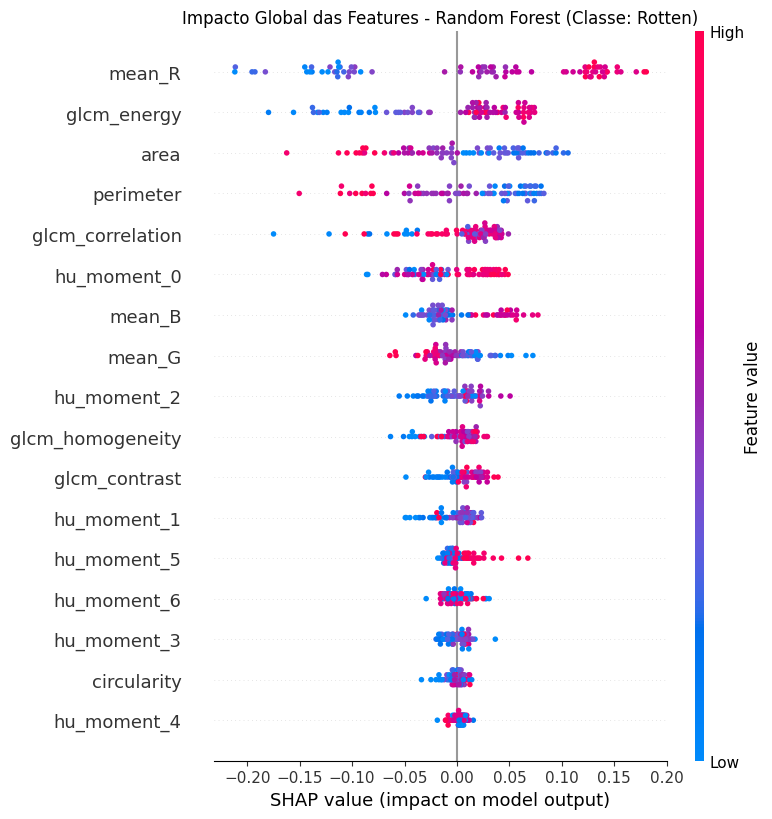

In [2]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_df)

if isinstance(shap_values, list):
    valores_classe_alvo = shap_values[1] 
else:
    valores_classe_alvo = shap_values[:, :, 1] if len(shap_values.shape) > 2 else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(valores_classe_alvo, X_test_df, show=False)
plt.title("Impacto Global das Features - Random Forest (Classe: Rotten)")
plt.tight_layout()
plt.show()

## Explicação Local (Analisando uma Fruta Específica)
O `waterfall_plot` isola a predição de um único item (ex: uma maçã podre) e decompõe exatamente como cada feature empurrou a probabilidade para a decisão final, permitindo análises de erros e acertos pontuais.

/home/akdag/Desktop/vis_computacional/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Rótulo Real da imagem: fresh
Previsão do Modelo: fresh


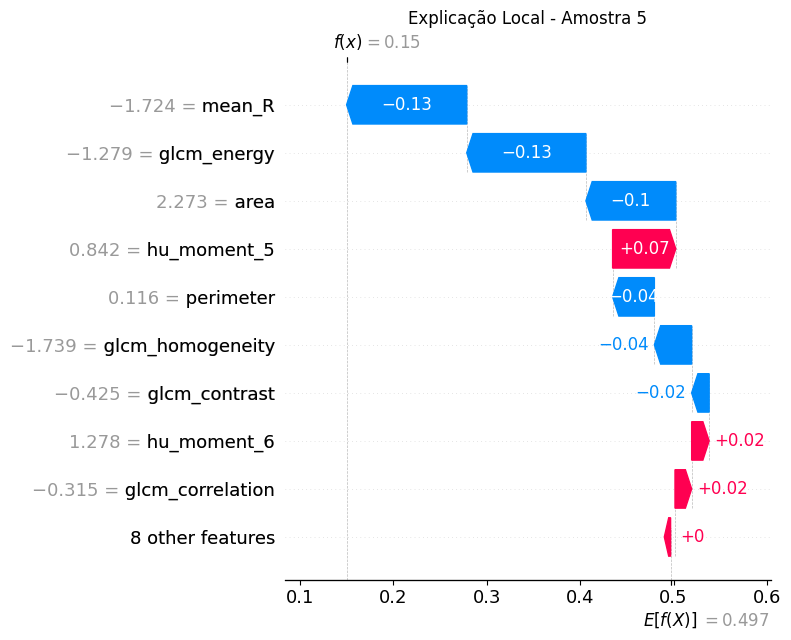

In [3]:
indice_amostra = 5 

if hasattr(explainer, "expected_value") and isinstance(explainer.expected_value, list):
    valor_base = explainer.expected_value[1]
else:
    valor_base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, tuple, np.ndarray)) else explainer.expected_value

objeto_shap = shap.Explanation(
    values=valores_classe_alvo[indice_amostra],
    base_values=valor_base,
    data=X_test_df.iloc[indice_amostra].values,
    feature_names=X_test_df.columns
)

predicao_real = y_test.iloc[indice_amostra]
predicao_modelo = rf_model.predict(X_test_df.iloc[[indice_amostra]])[0]

print(f"Rótulo Real da imagem: {predicao_real}")
print(f"Previsão do Modelo: {predicao_modelo}")

plt.figure(figsize=(8, 5))
shap.plots.waterfall(objeto_shap, show=False)
plt.title(f"Explicação Local - Amostra {indice_amostra}")
plt.tight_layout()
plt.show()